# **심장 질환 예측 모델 (Heart Disease Classification)**
---

**<분석 목적>**  

환자의 임상 데이터를 기반으로 심장 질환 발병 가능성을 예측하는 분류 모델을 구축하고, 각 모델의 성능을 비교 분석하는 것


**데이터셋:**
- Heart Disease Prediction Dataset (UCI Machine Learning Repository)
- 918개의 샘플과 11개의 변수로 구성
- 변수 정보
  
  Age: age of the patient [years]

  Sex: sex of the patient [M: Male, F: Female]

  ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

  RestingBP: resting blood pressure [mm Hg]

  Cholesterol: serum cholesterol [mm/dl]
  
  FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
  
  RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or 
  depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
  
  MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
  
  ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
  
  Oldpeak: oldpeak = ST [Numeric value measured in depression]
  
  ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
  
  HeartDisease: output class [1: heart disease, 0: Normal]

## 0. Install & Import

In [1]:
# 필요 시 설치 (약 5분 소요)

%pip install numpy pandas seaborn matplotlib plotly scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [57]:
# 라이브러리 임포트

import os
import numpy as np 
import pandas as pd 
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.decomposition import PCA
import matplotlib 

## 1. EDA

In [58]:
df = pd.read_csv("heart_disease_data.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [59]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [4]:
# Shows the Distribution of Heat Diseases with respect to male and female
fig=px.histogram(df, 
                 x="HeartDisease",
                 color="Sex",
                 hover_data=df.columns,
                 title="Distribution of Heart Diseases",
                 barmode="group")
fig.show()

In [5]:
fig=px.histogram(df,
                 x="ChestPainType",
                 color="Sex",
                 hover_data=df.columns,
                 title="Types of Chest Pain"
                )
fig.show()

In [6]:
fig=px.histogram(df,
                 x="Sex",
                 hover_data=df.columns,
                 title="Sex Ratio in the Data")
fig.show()

In [7]:
fig=px.histogram(df,
                 x="RestingECG",
                 hover_data=df.columns,
                 title="Distribution of Resting ECG")
fig.show()

[]

<Figure size 1500x1000 with 0 Axes>

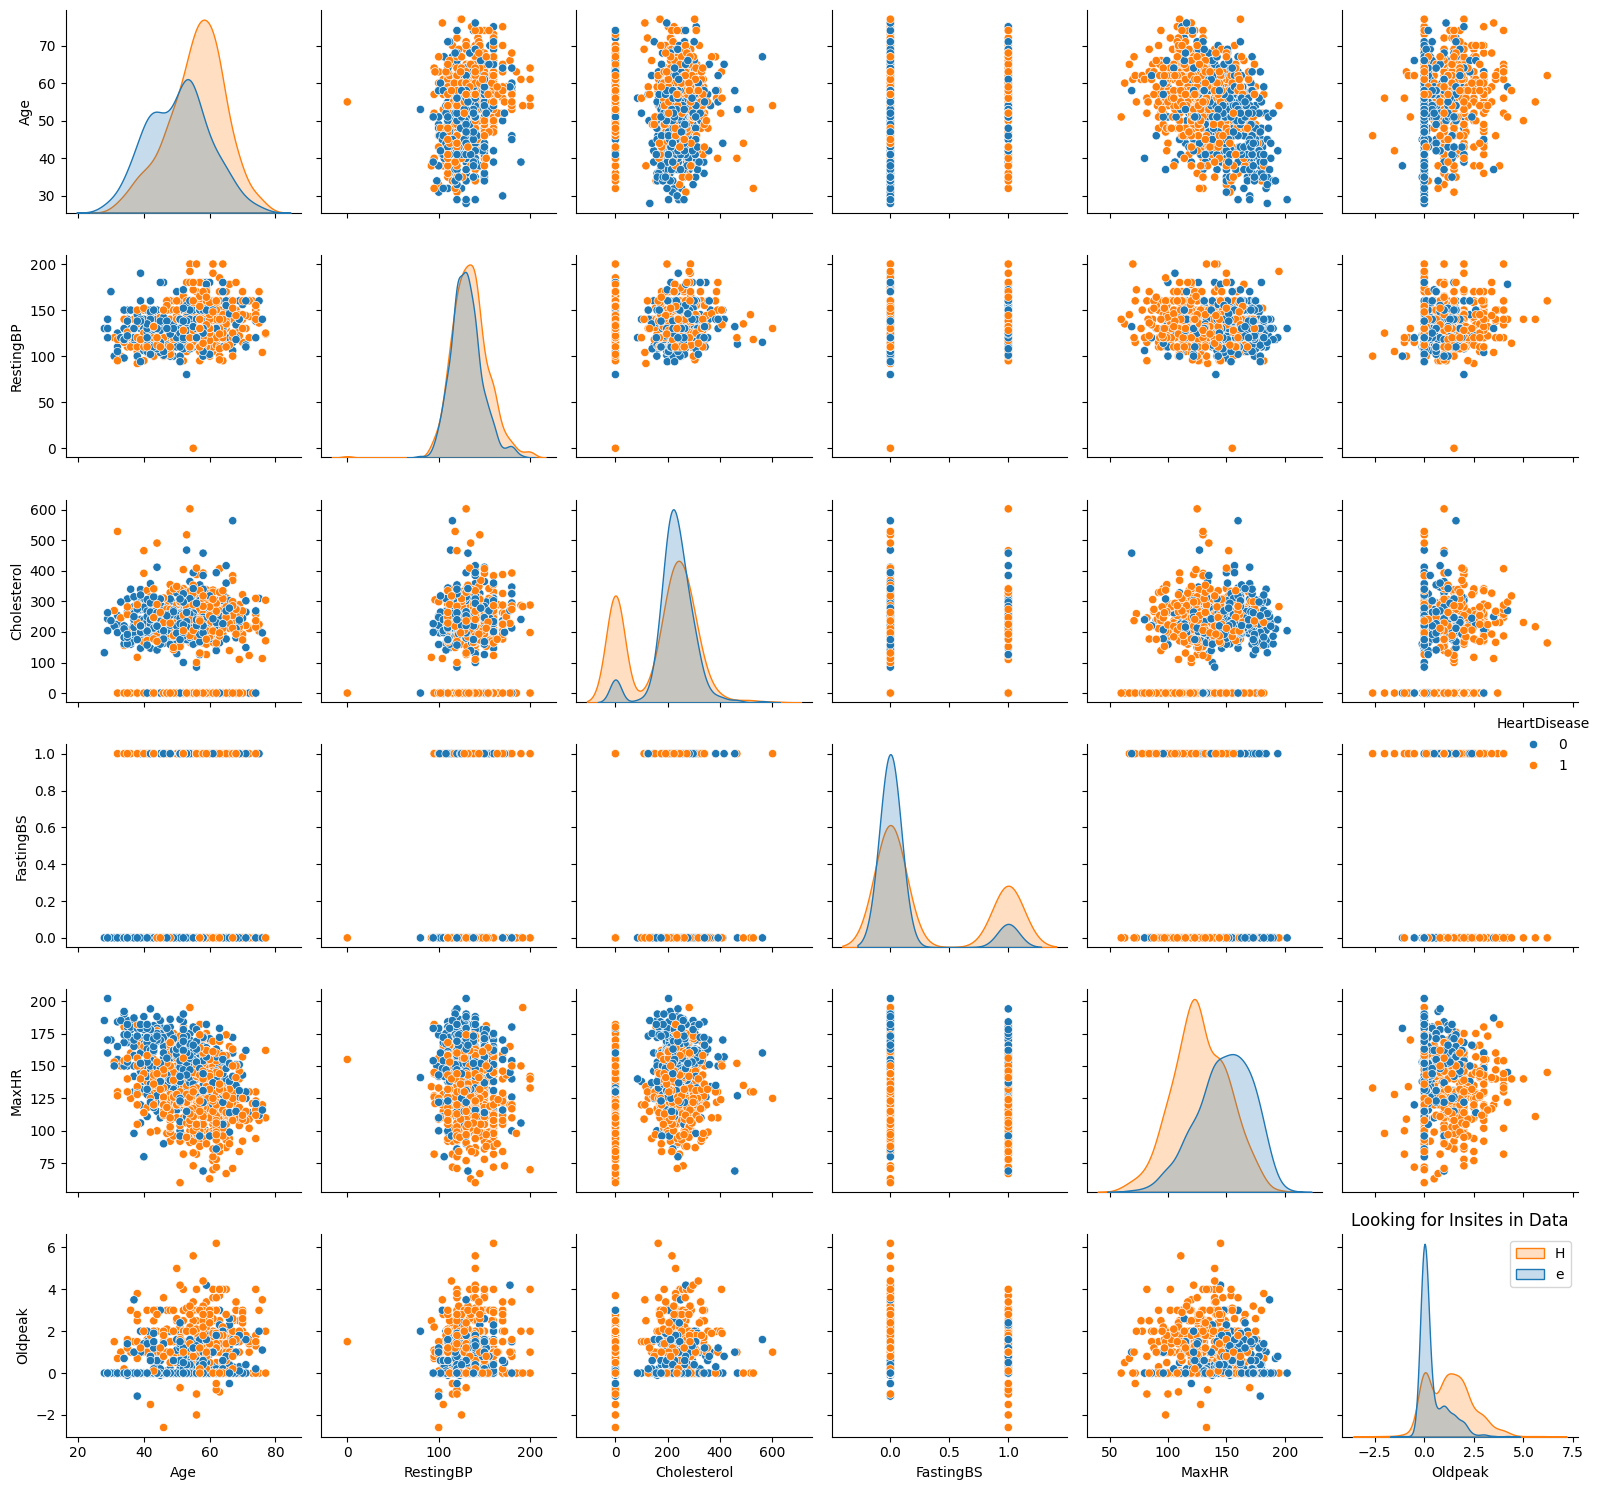

In [8]:
plt.figure(figsize=(15,10))
sns.pairplot(df,hue="HeartDisease")
plt.title("Looking for Insites in Data")
plt.legend("HeartDisease")
plt.tight_layout()
plt.plot()

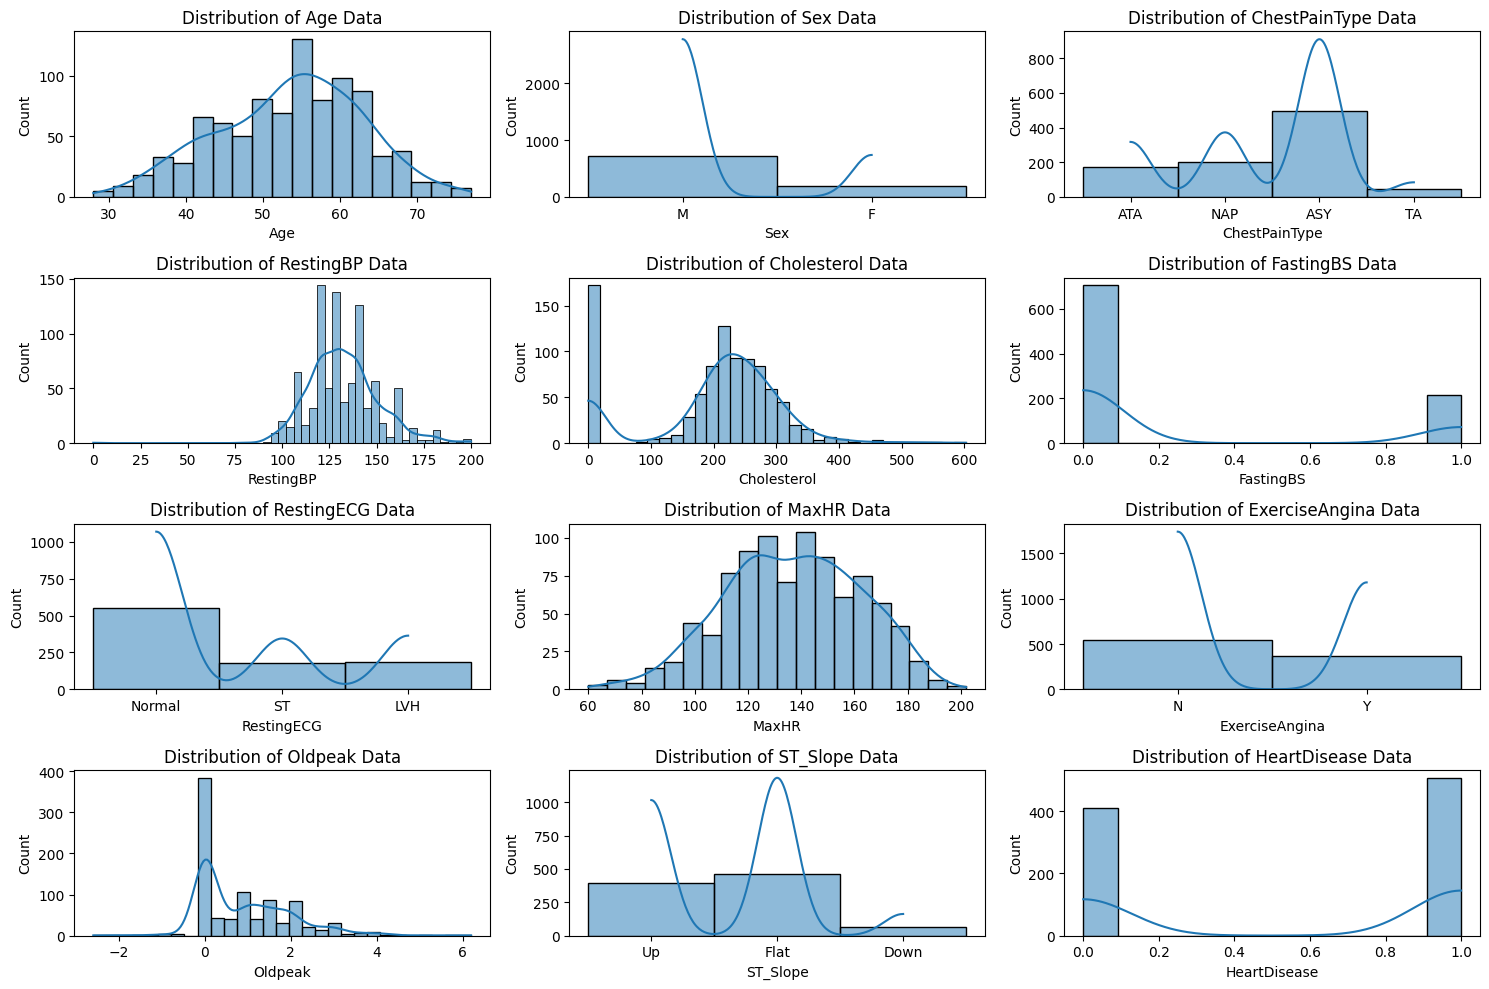

In [9]:
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns,1):
    plt.subplot(4,3,i)
    plt.title(f"Distribution of {col} Data")
    sns.histplot(df[col],kde=True)
    plt.tight_layout()
    plt.plot()

In [10]:
fig = px.box(df,y="Age",x="HeartDisease",title=f"Distrubution of Age")
fig.show()

In [11]:
fig = px.box(df,y="RestingBP",x="HeartDisease",title=f"Distrubution of RestingBP",color="Sex")
fig.show()

In [12]:
fig = px.box(df,y="Cholesterol",x="HeartDisease",title=f"Distrubution of Cholesterol")
fig.show()

In [13]:
fig = px.box(df,y="Oldpeak",x="HeartDisease",title=f"Distrubution of Oldpeak")
fig.show()

In [ ]:
fig = px.box(df,y="MaxHR",x="HeartDisease",title=f"Distrubution of MaxHR")
fig.show()

In [60]:
#추가 eda
df["HeartDisease"].value_counts(normalize=True)

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

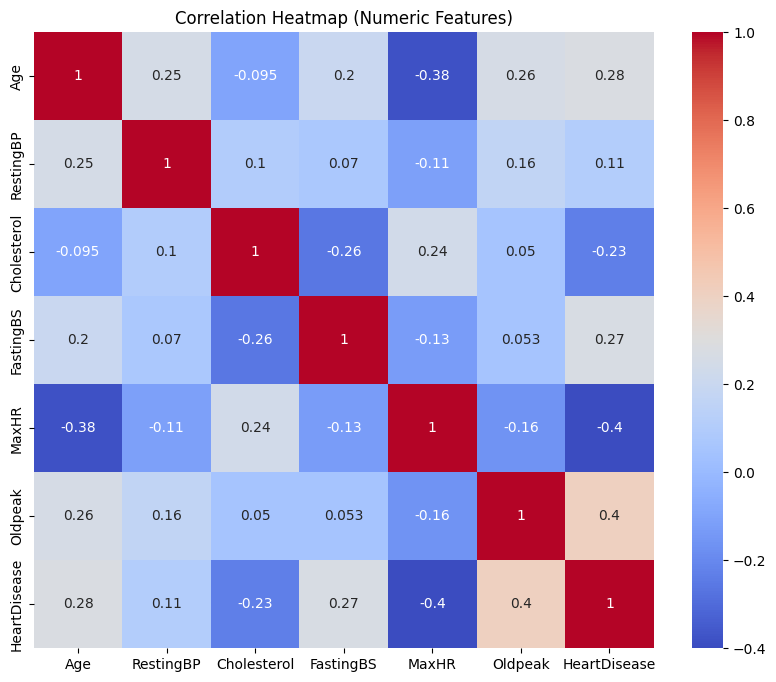

In [61]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


---

## 2. Data Preprocessing

In [62]:
# Checking for Type of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [63]:
# Checking for NULLs in the data
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [64]:
# 범주형 변수 목록
categorical_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# 각 범주형 변수를 Label Encoding으로 변환 (M/F, Y/N, 등)
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Label Encoding 후 데이터 확인
print(df.head())

   Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0   40    1              1        140          289          0           1   
1   49    0              2        160          180          0           1   
2   37    1              1        130          283          0           2   
3   48    0              0        138          214          0           1   
4   54    1              2        150          195          0           1   

   MaxHR  ExerciseAngina  Oldpeak  ST_Slope  HeartDisease  
0    172               0      0.0         2             0  
1    156               0      1.0         1             1  
2     98               0      0.0         2             0  
3    108               1      1.5         1             1  
4    122               0      0.0         2             0  


In [65]:
# 타겟 설정 및 데이터 분리
target = "HeartDisease"
X = df.drop(target, axis=1)
y = df[target]

# 변수명(feature_names)을 자동으로 추출
data = type('', (), {})()  # 빈 객체 생성
data.feature_names = X.columns  # feature_names 설정
data.target_names = np.array(['No HeartDisease', 'HeartDisease'])  # 타겟 클래스 이름 설정, numpy 배열로 처리

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링 (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---

## 3. 모델 적용

### 1) Logistic Regression

In [11]:
# 모델 정의 및 학습
LR_model = LogisticRegression(max_iter=10000)
LR_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [66]:
# Coefficients(계수) 및 Intercept(절편) 출력
coefficients = LR_model.coef_[0]  # 계수 (이진 분류의 경우 첫 번째 클래스의 계수)
intercept = LR_model.intercept_  # 절편

# 변수명, 계수, 오즈 매핑
feature_names = data.feature_names
Odds= np.exp(coefficients) # 오즈비!
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients, 'Odds': Odds})

print(coef_df)

           Feature  Coefficient      Odds
0              Age     0.138855  1.148958
1              Sex     0.497190  1.644094
2    ChestPainType    -0.565943  0.567825
3        RestingBP     0.064559  1.066688
4      Cholesterol    -0.493395  0.610550
5        FastingBS     0.404029  1.497847
6       RestingECG    -0.174062  0.840245
7            MaxHR    -0.200766  0.818104
8   ExerciseAngina     0.626233  1.870551
9          Oldpeak     0.483624  1.621941
10        ST_Slope    -1.009281  0.364481


In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 모델 예측
y_pred = LR_model.predict(X_test) # 테스트 셋을 이용한 예측치
y_pred_proba = LR_model.predict_proba(X_test)[:, 1]  # 양성 클래스(1)에 대한 확률

# 성능 평가 지표 계산
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 결과 출력
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.8478
Precision: 0.9072
Recall: 0.8224
F1-score: 0.8627
ROC-AUC: 0.9008


### 2) Decision Tree

In [82]:
# Decision Tree 모델 정의 및 학습
from sklearn.tree import DecisionTreeClassifier

DT_model = DecisionTreeClassifier(random_state=42)
DT_model.fit(X_train, y_train)

# 예측
y_pred = DT_model.predict(X_test)

In [83]:
from sklearn.model_selection import GridSearchCV  

# 하이퍼파라미터 후보군 설정
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None]
}

# Grid Search 실행
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# 최적의 파라미터 출력
print(grid_search.best_params_)



{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}


|--- ST_Slope <= 0.25
|   |--- ChestPainType <= -0.28
|   |   |--- Sex <= -0.65
|   |   |   |--- Oldpeak <= 0.36
|   |   |   |   |--- Age <= 0.95
|   |   |   |   |   |--- RestingECG <= -0.78
|   |   |   |   |   |   |--- RestingBP <= 0.51
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- RestingBP >  0.51
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- RestingECG >  -0.78
|   |   |   |   |   |   |--- MaxHR <= 0.01
|   |   |   |   |   |   |   |--- Cholesterol <= -0.94
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Cholesterol >  -0.94
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- MaxHR >  0.01
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Age >  0.95
|   |   |   |   |   |--- class: 1
|   |   |   |--- Oldpeak >  0.36
|   |   |   |   |--- RestingBP <= -0.93
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- RestingBP >  -0.93
|   |   |   |   |   |--- class: 1
|   |   |-

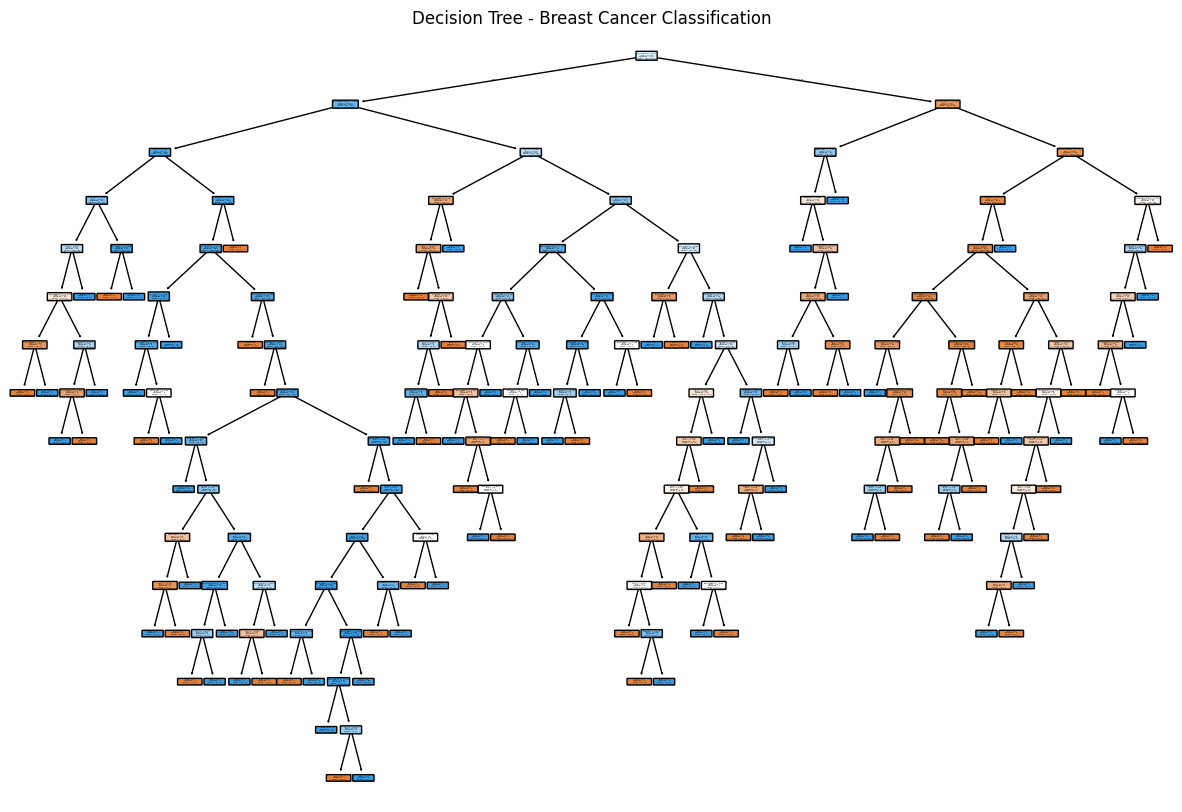

In [84]:
# 트리 규칙을 텍스트로 출력
tree_rules = tree.export_text(DT_model, feature_names=list(data.feature_names))
print(tree_rules)

# 트리 구조를 이미지로 출력
plt.figure(figsize=(15, 10))
tree.plot_tree(DT_model, feature_names=data.feature_names, class_names=data.target_names, filled=True, rounded=True)
plt.title("Decision Tree - Breast Cancer Classification")
plt.show()

In [85]:
# 모델 성능 지표 출력
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Classification Report:

                 precision    recall  f1-score   support

No HeartDisease       0.71      0.83      0.77        77
   HeartDisease       0.86      0.76      0.81       107

       accuracy                           0.79       184
      macro avg       0.79      0.79      0.79       184
   weighted avg       0.80      0.79      0.79       184



### 3) Random Forest 

In [73]:
# 랜덤 포레스트 모델 정의 및 학습
RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
RF_model.fit(X_train, y_train)

# 예측
y_pred = RF_model.predict(X_test)

In [74]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)  # 최적의 파라미터 출력


{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. 최적 모델 가져오기
best_rf = grid_search.best_estimator_


y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]  


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("RandomForest (Best Params):")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")




RandomForest (Best Params):
Accuracy : 0.8913
Precision: 0.9143
Recall   : 0.8972
F1-score : 0.9057
ROC-AUC  : 0.9442


### 4) SVM

In [76]:
# PCA로 차원 축소 (시각화를 위해 2차원으로)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [77]:
# SVM 모델 정의 및 학습
SVM_model = SVC(kernel='linear', C=1.0, random_state=42) # 선형(직선)으로 데이터를 나눌 것이다! / 어느 정도로 학습 데이터에 맞출 것이다! 라는 뜻
SVM_model.fit(X_train_pca, y_train)

# 예측
y_pred = SVM_model.predict(X_test_pca)

In [78]:

# 탐색할 하이퍼파라미터 설정
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 'scale'],
    'kernel': ['rbf', 'linear']
}

# Grid Search 실행
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_pca, y_train)

# 최적 하이퍼파라미터 확인
print(grid_search.best_params_)


{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}


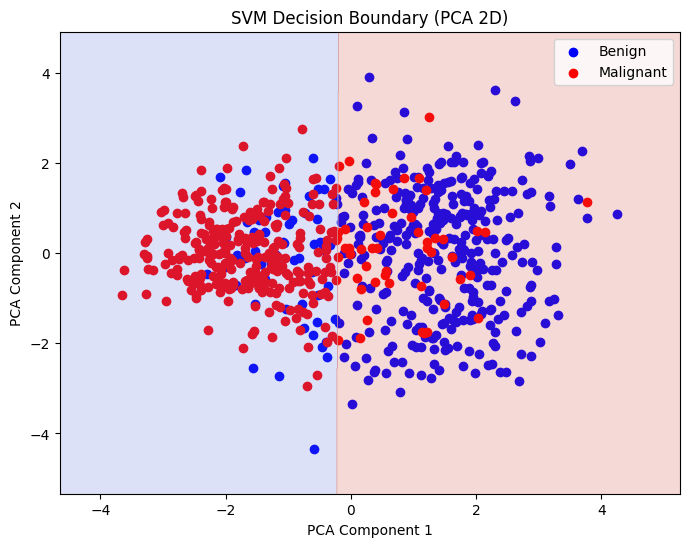

In [79]:
# 시각화 (PCA를 통해 2차원 공간에서 시각화)
plt.figure(figsize=(8, 6))

# 양성과 악성 데이터를 다른 색상으로 표시
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], color='blue', label='Benign')
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], color='red', label='Malignant')

# 결정 경계 시각화
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = SVM_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')

plt.title('SVM Decision Boundary (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
import numpy as np

# 확률 필요하면 probability=True (속도 느려짐)
svc = SVC(random_state=42, probability=True)

param_grid = [
    {"kernel": ["linear"], "C": [0.1, 1, 10]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10], "gamma": [0.001, 0.01, 0.1, "scale"]},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(svc, param_grid, cv=cv, scoring="f1", n_jobs=-1)
gs.fit(X_train_pca, y_train)

print("Best params:", gs.best_params_)

# 테스트 성능
y_pred = gs.predict(X_test_pca)
y_prob = gs.predict_proba(X_test_pca)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")



Best params: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy : 0.8261
Precision: 0.9121
Recall   : 0.7757
F1-score : 0.8384
ROC-AUC  : 0.8869


---

## 4. 모델 평가

**최적 모델 선정:** 랜덤 포레스트

**이유:**    
-Accuracy, Recall, F1-score, ROC-AUC 모두 가장 높음   
-특히 의료 분야에서는 재현율이 가장 중요(심장질환 환자 놓칠 확률을 크게 줄여줌)      
-변수 중요도 해석 가능     


---

## 5. 주요 변수 추출 및 해석

### 5.1 모델 성능 해석

- **랜덤 포레스트**가 성과지표 결과, 가장 안정적인 최적의 모델로 선정         
- **로지스틱 회귀**: 해석력 측면에서 강점(변수의 영향 설명)          
- **SVM**: 정밀도가 0.9121로 높아 양성 판정을 신뢰할 수 있으나, 재현율이 낮아 환자 일부를 놓칠 가능성 있음!         
- **의사결정나무**: 성능 상대적으로 낮음      

### 5.2 주요 변수 추출

**(1) 로지스틱 회귀**

- 양의 계수:       
    - 성별 (sex): 남성이 여성보다 심장질환 위험이 높음.    
    - 운동 중 협심증 (ExerciseAngina): 운동 시 흉통 경험이 있으면 위험도 증가.        
    - 운동 후 ST 하강 (oldpeak):ST 하강 수치가 높을수록 위험도 증가.     
    - 나이, 고혈당, 고혈압이 위험 요인임을 반영함.                   
    

- 음의 계수:    
    - 흉통 유형: 일부 유형은 OR<1 -> 특정 흉통 유형이 심장질환과 덜 관련됨.   
    - ST_Slope (ST 분절 기울기): ST slope이 정상적이면 위험 감소.


**(2) 의사결정나무**

           Feature  Importance
10        ST_Slope    0.597863
4      Cholesterol    0.084586
2    ChestPainType    0.069203
1              Sex    0.052757
8   ExerciseAngina    0.043460
9          Oldpeak    0.040955
7            MaxHR    0.032851
3        RestingBP    0.027984
5        FastingBS    0.027550
0              Age    0.014710
6       RestingECG    0.008080


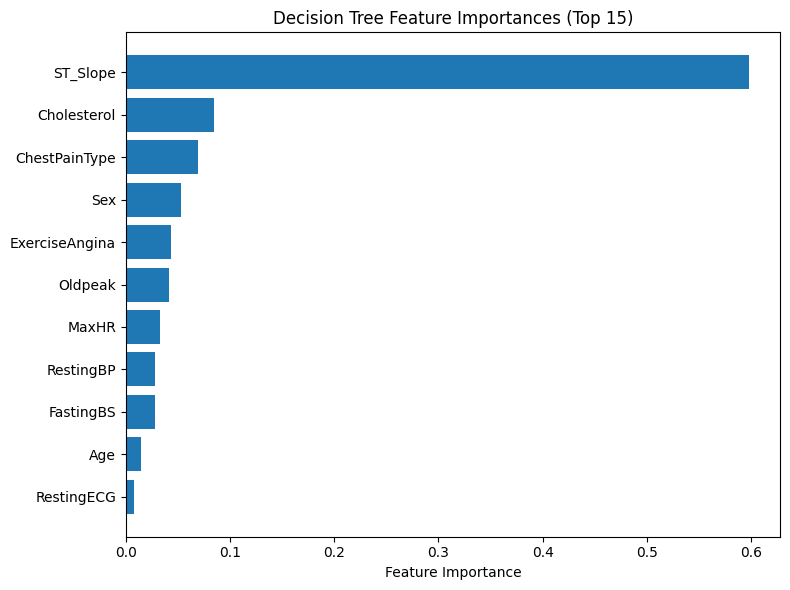

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

dt_best = grid_search.best_estimator_   # 이미 찾은 최적 DT
feat = X.columns                        # 원본 컬럼명
imp  = dt_best.feature_importances_

fi_dt = pd.DataFrame({"Feature": feat, "Importance": imp})\
           .sort_values("Importance", ascending=False)
print(fi_dt.head(20))

# 상위 15개 시각화
topk = 15
plt.figure(figsize=(8,6))
plt.barh(fi_dt.head(topk)["Feature"], fi_dt.head(topk)["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importances (Top 15)")
plt.tight_layout()
plt.show()


- ST_Slope (압도적으로 중요한 변수, 중요도 ≈ 60%)       
    - 심전도 운동 후 ST 분절 기울기 -> 심장혈류 이상을 강하게 반영
    -의사결정나무는 ST_Slope에 의존도가 매우 큼(단일 변수에 과적합 위험 존재)

- Cholesterol (≈ 8%)     
    - 심혈관계 위험 인자로 잘 알려진 변수
    

                                 
                                                             
                                                                      

**(3) 랜덤포레스트**

           Feature  Importance
10        ST_Slope    0.253394
9          Oldpeak    0.118648
8   ExerciseAngina    0.111509
2    ChestPainType    0.108804
4      Cholesterol    0.100105
7            MaxHR    0.096172
0              Age    0.078294
3        RestingBP    0.057086
1              Sex    0.034892
6       RestingECG    0.021139
5        FastingBS    0.019957


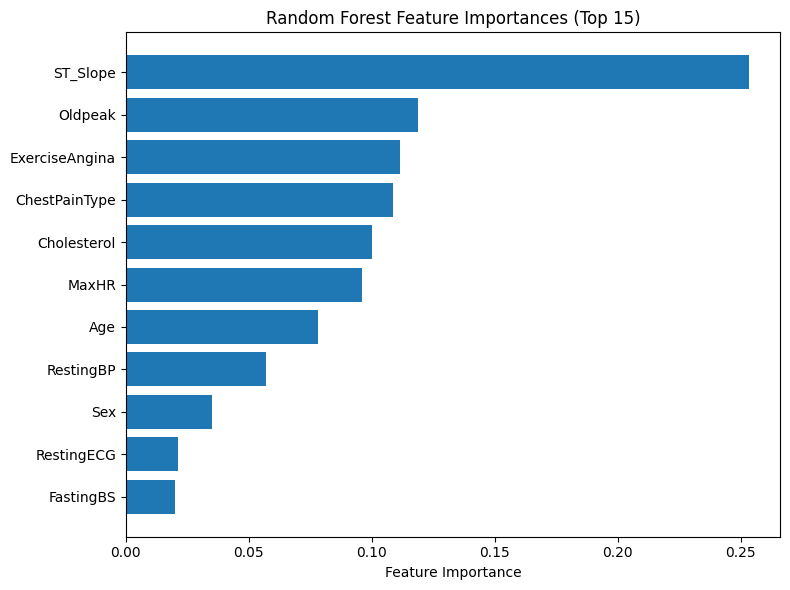

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 중요도 표
features = X.columns  # 원본 컬럼명
importances = best_rf.feature_importances_
fi_df = pd.DataFrame({"Feature": features, "Importance": importances}) \
           .sort_values("Importance", ascending=False)
print(fi_df.head(20))  # 상위 20개 확인

# 2) 중요도 시각화 (상위 15개)
topk = 15
plt.figure(figsize=(8, 6))
plt.barh(fi_df.head(topk)["Feature"], fi_df.head(topk)["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (Top 15)")
plt.tight_layout()
plt.show()


- ST_Slope (가장 중요한 변수, 중요도 ≈ 25%)       
    - 운동부하검사 후 ST분절의 기울기. 비정상적인 slope는 심근허혈과 관련이 높음.

- Oldpeak (≈ 11.9%)     
    - 운동 후 ST 하강 정도. 값이 클수록 허혈 가능성↑ -> 심장질환 위험 증가.

- ExerciseAngina (≈ 11.2%)     
    - 운동 중 협심증 경험 여부. 환자의 실제 증상과 직결되는 강력한 위험 인자.

      
-> 운동 관련 지표(ST_Slope, Oldpeak, ExerciseAngina)가 가장 강력한 예측 요인.     

                                 
                                                             
                                                                      

---

### 5.3 변수 해석

**(1) 로지스틱회귀**  
      
- 성별(OR=1.64)   
    - 남성은 여성보다 심혈관 질환 발병률이 높음
      
- 운동 중 협심증(OR=1.87)-> 주요 보호 인자     
    - 협심증은 관상동맥 협착의 대표적 증상. 운동 부하 시 산소 요구량이 증가하면서 혈류가 부족해 흉통 발생 -> 이는 실제 임상에서 가장 강력한 심질환 의심 지표.


**(2) 랜덤 포레스트**  
      
- ST_Slope   
    - slope는 허혈을 시사-> 심장질환 위험 높음
      
- Oldpeak    
    - 값이 높을수록 허혈이 심하다는 뜻 -> 관상동맥 질환 가능성 ↑.


---

## 6. 결론 및 인사이트

**(1) 연구 목적 정리**                  
        
본 프로젝트는 환자 데이터를 기반으로 심장 질환 위험도를 예측하는 분류 모델을 구축하는 데 목적이 있음.
이를 통해

- 고위험군 환자의 조기 발견,
- 맞춤형 예방 전략 수립,
- 의료 자원의 효율적 배분에 기여하고자 함

       
**(2) 분석 결과**    
                       
- 최종 모델: 랜덤 포레스트    
- 선택 이유: 높은 성과지표와 변수 중요도 해석      
- 선택 하이퍼파라미터(이유):    
    - max_depth: 15 (적다한 복잡도 유지하면서 환자 데이터에 적용했을 때, 일반화 성능 높일 수 있음)   
    - min_samples_leaf: 1     
    - min_samples_split: 5 (노이즈에 민감하게 반응하지 않도록 제어)    
    - n_estimators: 300 (트리 개수 많을수록 안정적, 편향 줄임)                                                              

         

**(3) 인사이트**       
                                  
- **누구에게:**             
    - 헬스케어 서비스 (예방 중심의 관리 서비스 제공 기업)     
           
- **어떤 가치를:**         
    - 개인의 심장질환 발병 위험도를 사전에 검사 및 확인
    - 맞춤형 진단, 치료 전략 수립 지원
  
                 
- **어떻게:**             
    - 서비스(앱)에 병원/보건소 검사 시 측정된 기본 지표 입력(혈압, 콜레스테롤 등)          
    - 특히 운동 관련 지표 확인 (운동부하검사)    
    - 구축된 랜덤포레스트 기반 예측 모델로 환자 위험도 점수화   
          
- **어떤 가격으로:**             
    - 저렴한 B2C 모바일 앱 구독형 서비스           
       
- **얻는 방법:**             
    - 병원 진료 시 안내되는 앱 다운로드 및 검사 결과 연동              